# NELA-GT EDA

Exploratory analysis of the NELA-GT 500k sampled dataset (3-class: Reliable / Questionable / Conspiracy).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

LABEL_NAMES = {0: 'Reliable', 1: 'Questionable', 2: 'Conspiracy'}
LABEL_COLORS = {0: '#2ecc71', 1: '#e67e22', 2: '#e74c3c'}
plt.rcParams['figure.dpi'] = 120

train = pd.read_csv('../data/processed/nela_sampled_500k/train.csv', dtype={'label': 'int8'})
val   = pd.read_csv('../data/processed/nela_sampled_500k/val.csv',   dtype={'label': 'int8'})
test  = pd.read_csv('../data/processed/nela_sampled_500k/test.csv',  dtype={'label': 'int8'})
df = pd.concat([train, val, test], ignore_index=True)
df['label_name'] = df['label'].map(LABEL_NAMES)
df['word_count'] = df['text'].str.split().str.len()

print(f'Total articles : {len(df):,}')
print(f'Train/Val/Test : {len(train):,} / {len(val):,} / {len(test):,}')
print(f'Publishers     : {df["source"].nunique()}')
print(f'Columns        : {list(df.columns)}')

Total articles : 500,000
Train/Val/Test : 399,938 / 50,018 / 50,044
Publishers     : 457
Columns        : ['text', 'label', 'source', 'label_name', 'word_count']


## 1. Class Distribution

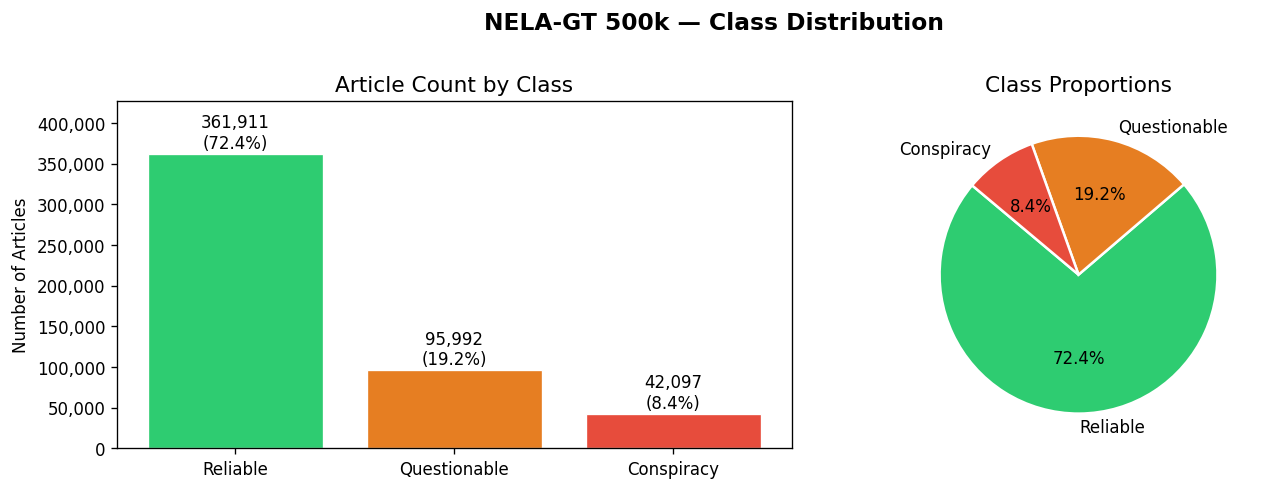

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['label'].value_counts().sort_index()
bars = axes[0].bar(
    [LABEL_NAMES[i] for i in counts.index],
    counts.values,
    color=[LABEL_COLORS[i] for i in counts.index],
    edgecolor='white', linewidth=0.8
)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{cnt:,}\n({100*cnt/len(df):.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Article Count by Class', fontsize=13)
axes[0].set_ylabel('Number of Articles')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_ylim(0, counts.max() * 1.18)

# Pie chart
axes[1].pie(
    counts.values,
    labels=[LABEL_NAMES[i] for i in counts.index],
    colors=[LABEL_COLORS[i] for i in counts.index],
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Class Proportions', fontsize=13)

plt.suptitle('NELA-GT 500k — Class Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/nela_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Article Length Distribution

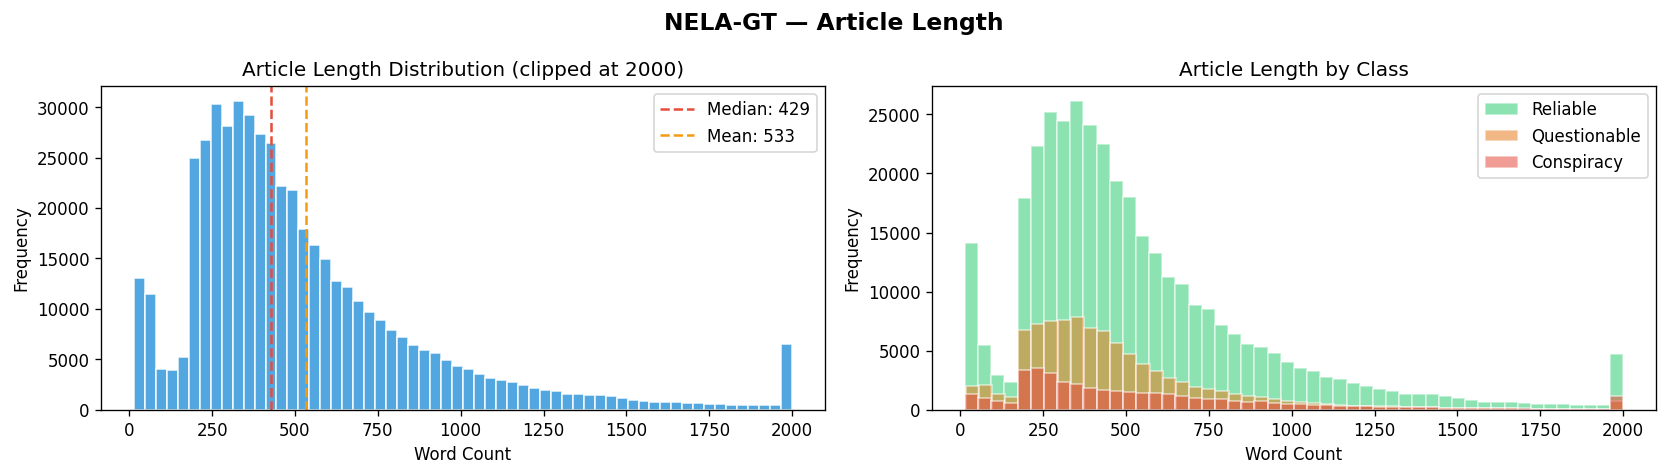

Word count stats per class:
               mean    50%    std   min     max
label_name                                     
Conspiracy    588.0  437.0  499.0  14.0  3747.0
Questionable  479.0  399.0  338.0  16.0  3554.0
Reliable      542.0  438.0  398.0  14.0  3761.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall histogram
axes[0].hist(df['word_count'].clip(upper=2000), bins=60, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(df['word_count'].median(), color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'Median: {df["word_count"].median():.0f}')
axes[0].axvline(df['word_count'].mean(), color='#f39c12', linestyle='--', linewidth=1.5,
                label=f'Mean: {df["word_count"].mean():.0f}')
axes[0].set_title('Article Length Distribution (clipped at 2000)', fontsize=12)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# By class
for lbl in sorted(LABEL_NAMES):
    axes[1].hist(
        df[df['label'] == lbl]['word_count'].clip(upper=2000),
        bins=50, alpha=0.55, color=LABEL_COLORS[lbl],
        label=LABEL_NAMES[lbl], edgecolor='white'
    )
axes[1].set_title('Article Length by Class', fontsize=12)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('NELA-GT — Article Length', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/nela_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Word count stats per class:')
print(df.groupby('label_name')['word_count'].describe()[['mean','50%','std','min','max']].round(0))

## 3. Publisher Distribution

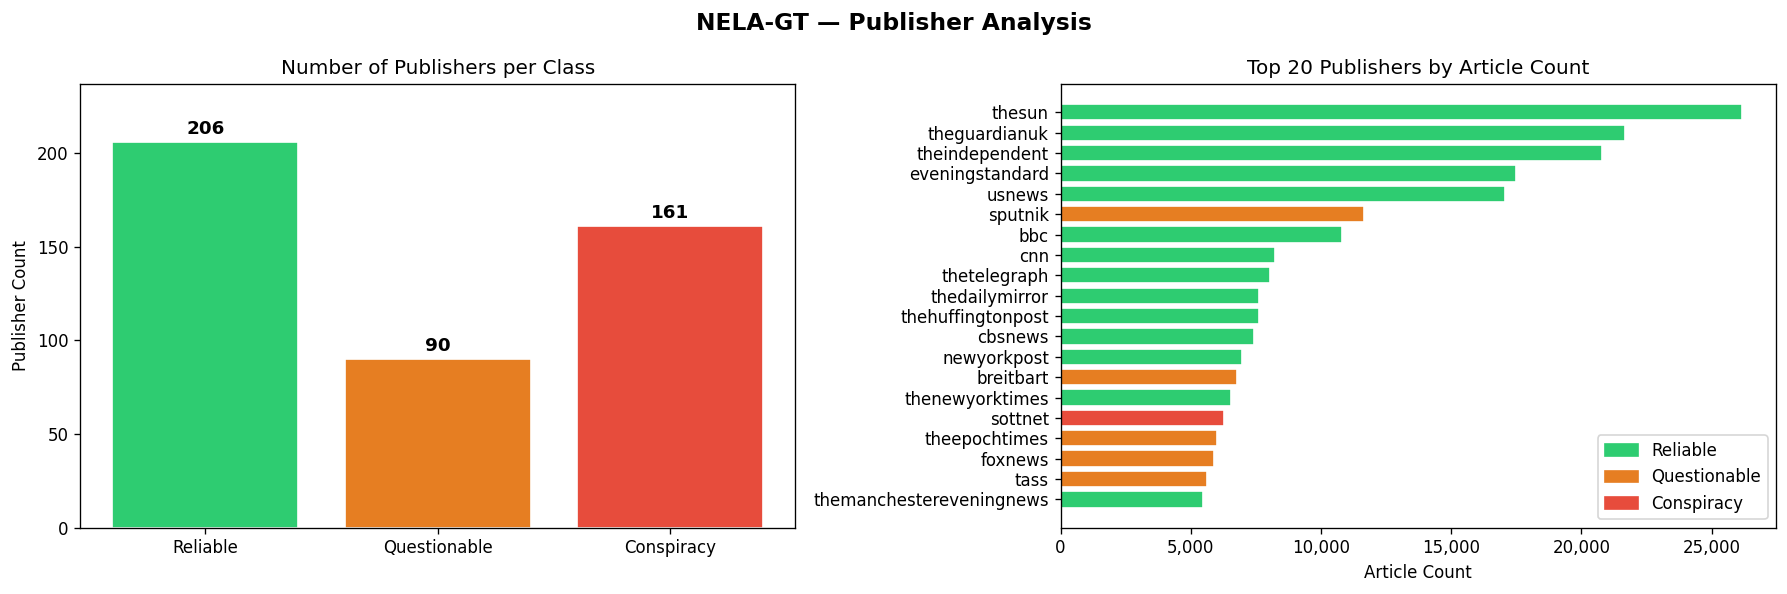

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Publishers per class
pub_per_class = df.groupby('label')['source'].nunique().sort_index()
bars = axes[0].bar(
    [LABEL_NAMES[i] for i in pub_per_class.index],
    pub_per_class.values,
    color=[LABEL_COLORS[i] for i in pub_per_class.index],
    edgecolor='white'
)
for bar, cnt in zip(bars, pub_per_class.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(cnt), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Number of Publishers per Class', fontsize=12)
axes[0].set_ylabel('Publisher Count')
axes[0].set_ylim(0, pub_per_class.max() * 1.15)

# Top 20 publishers by article count, coloured by class
top_pubs = df['source'].value_counts().head(20)
pub_labels = df.groupby('source')['label'].first()
colors = [LABEL_COLORS[pub_labels[p]] for p in top_pubs.index]

axes[1].barh(top_pubs.index[::-1], top_pubs.values[::-1], color=colors[::-1], edgecolor='white')
axes[1].set_title('Top 20 Publishers by Article Count', fontsize=12)
axes[1].set_xlabel('Article Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Legend
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=LABEL_COLORS[i], label=LABEL_NAMES[i]) for i in range(3)],
               loc='lower right')

plt.suptitle('NELA-GT — Publisher Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/nela_publisher_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Articles per Publisher (Source Diversity)

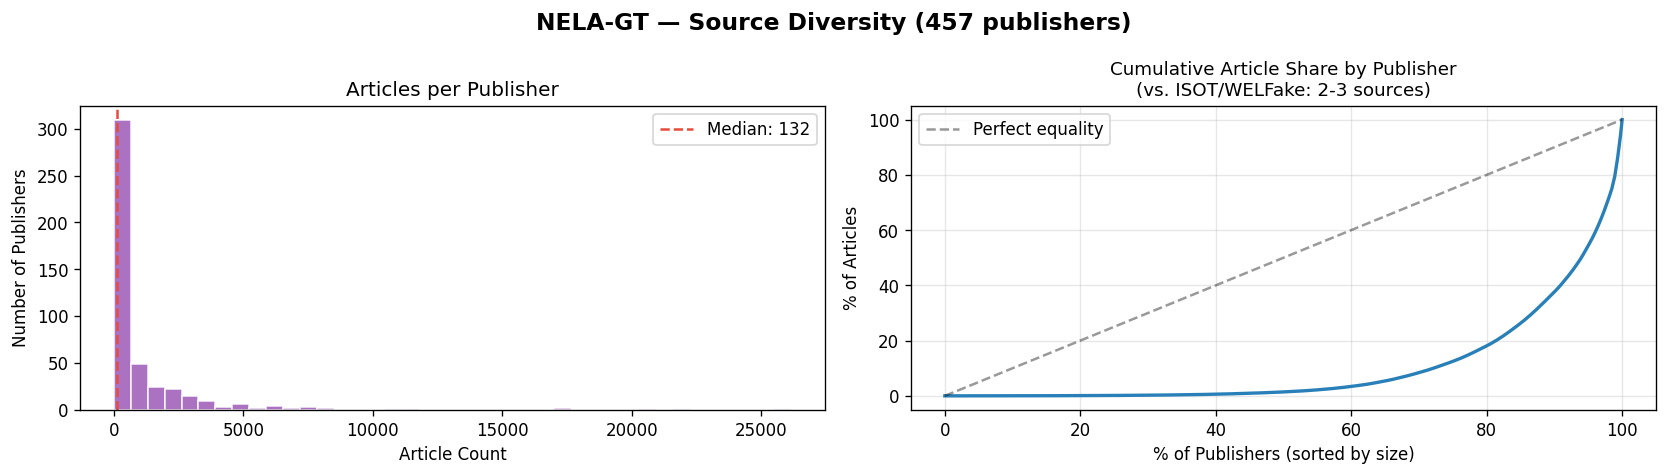

Articles per publisher — median: 132, mean: 1094, max: 26,161
Top 10 publishers account for 29.9% of articles


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of articles per publisher
pub_counts = df.groupby('source').size()
axes[0].hist(pub_counts, bins=40, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0].axvline(pub_counts.median(), color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'Median: {pub_counts.median():.0f}')
axes[0].set_title('Articles per Publisher', fontsize=12)
axes[0].set_xlabel('Article Count')
axes[0].set_ylabel('Number of Publishers')
axes[0].legend()

# Gini-style cumulative — shows how evenly distributed articles are
sorted_counts = np.sort(pub_counts.values)
cumulative = np.cumsum(sorted_counts) / sorted_counts.sum()
axes[1].plot(np.linspace(0, 100, len(cumulative)), cumulative * 100,
             color='#2980b9', linewidth=2)
axes[1].plot([0, 100], [0, 100], 'k--', alpha=0.4, label='Perfect equality')
axes[1].set_title('Cumulative Article Share by Publisher\n(vs. ISOT/WELFake: 2-3 sources)', fontsize=11)
axes[1].set_xlabel('% of Publishers (sorted by size)')
axes[1].set_ylabel('% of Articles')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('NELA-GT — Source Diversity (457 publishers)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/nela_source_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Articles per publisher — median: {pub_counts.median():.0f}, '
      f'mean: {pub_counts.mean():.0f}, max: {pub_counts.max():,}')
top10_share = pub_counts.nlargest(10).sum() / len(df) * 100
print(f'Top 10 publishers account for {top10_share:.1f}% of articles')

## 5. MBFC Label Breakdown (Original 8-class)

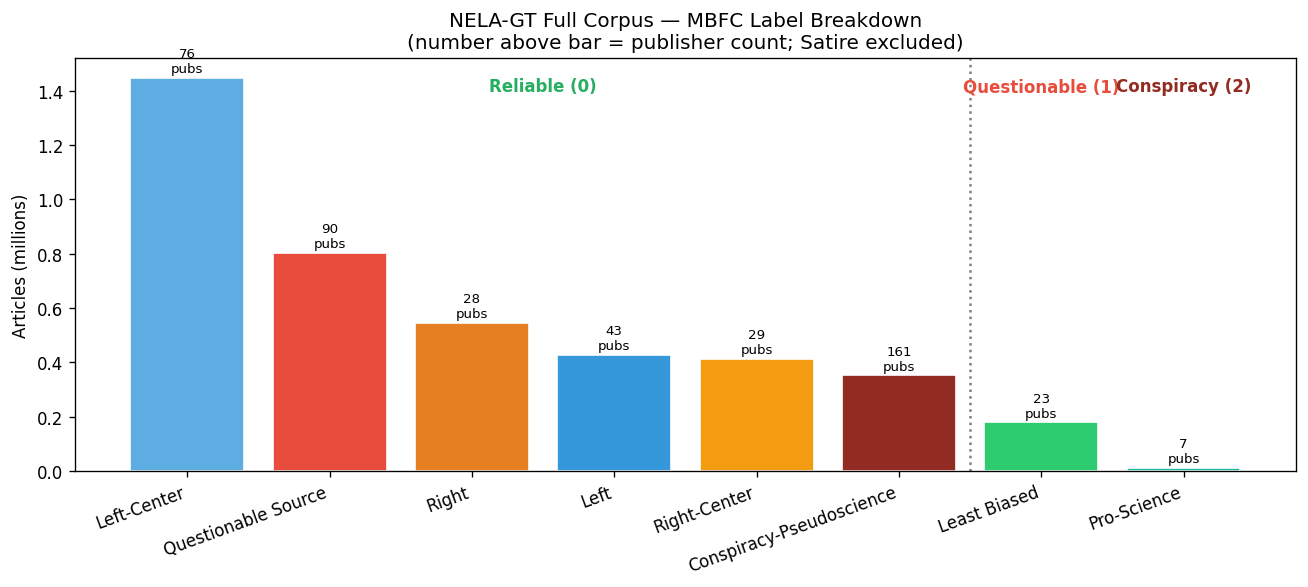

In [7]:
try:
    import duckdb
    con = duckdb.connect('../misinfo-general/metadata.db', read_only=True)
    mbfc = con.execute("""
        SELECT s.label as mbfc_label, COUNT(*) as n_articles,
               COUNT(DISTINCT s.source) as n_publishers
        FROM articles a JOIN sources s ON a.source = s.source
        WHERE s.label != 'Satire'
        GROUP BY s.label ORDER BY n_articles DESC
    """).df()
    con.close()

    fig, ax = plt.subplots(figsize=(11, 5))
    palette = {
        'Left': '#3498db', 'Left-Center': '#5dade2', 'Least Biased': '#2ecc71',
        'Right-Center': '#f39c12', 'Right': '#e67e22', 'Pro-Science': '#1abc9c',
        'Questionable Source': '#e74c3c', 'Conspiracy-Pseudoscience': '#922b21'
    }
    colors = [palette.get(l, '#95a5a6') for l in mbfc['mbfc_label']]
    bars = ax.bar(mbfc['mbfc_label'], mbfc['n_articles'] / 1e6, color=colors, edgecolor='white')
    for bar, row in zip(bars, mbfc.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{row.n_publishers}\npubs', ha='center', va='bottom', fontsize=8)
    ax.set_ylabel('Articles (millions)')
    ax.set_title('NELA-GT Full Corpus — MBFC Label Breakdown\n(number above bar = publisher count; Satire excluded)',
                 fontsize=12)
    plt.xticks(rotation=20, ha='right')

    # Bracket showing our 3-class collapse
    ax.axvline(5.5, color='black', linestyle=':', alpha=0.5)
    ax.text(2.5, ax.get_ylim()[1]*0.92, 'Reliable (0)', ha='center', fontsize=10,
            color='#27ae60', fontweight='bold')
    ax.text(6.0, ax.get_ylim()[1]*0.92, 'Questionable (1)', ha='center', fontsize=10,
            color='#e74c3c', fontweight='bold')
    ax.text(7.0, ax.get_ylim()[1]*0.92, 'Conspiracy (2)', ha='center', fontsize=10,
            color='#922b21', fontweight='bold')

    plt.tight_layout()
    plt.savefig('../results/nela_mbfc_breakdown.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'metadata.db not available ({e}) — skipping MBFC chart')

## 6. Top Unigrams per Class

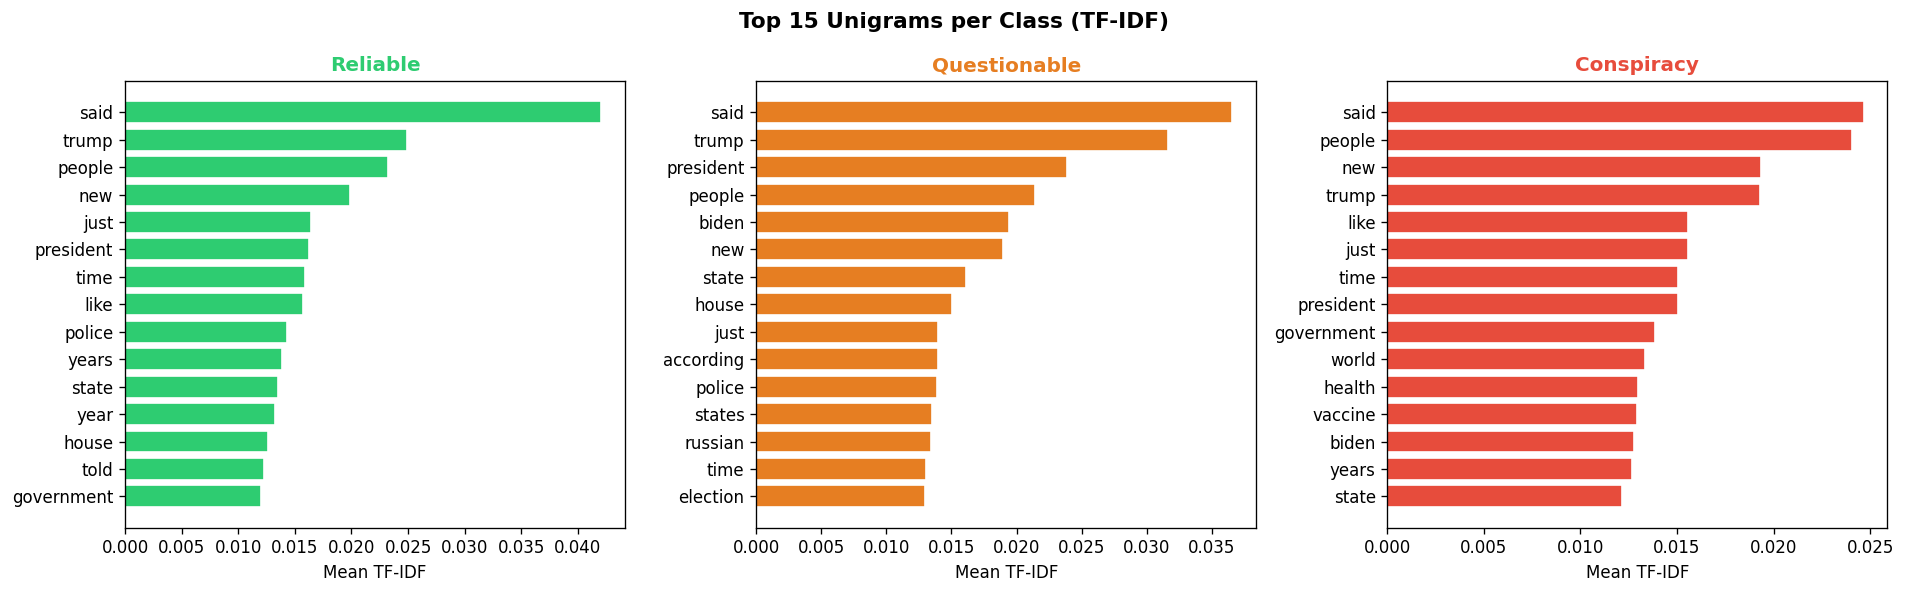

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for lbl, ax in zip(range(3), axes):
    # Sample directly from df per class — avoids groupby column-drop issue
    class_df = df[df['label'] == lbl].sample(min(10000, (df['label'] == lbl).sum()), random_state=42)
    texts = class_df['text'].tolist()

    vec = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 1))
    X = vec.fit_transform(texts)
    mean_tfidf = np.asarray(X.mean(axis=0)).flatten()
    top_idx = mean_tfidf.argsort()[-15:][::-1]
    words = [vec.get_feature_names_out()[i] for i in top_idx]
    scores = mean_tfidf[top_idx]

    ax.barh(words[::-1], scores[::-1], color=LABEL_COLORS[lbl], edgecolor='white')
    ax.set_title(f'{LABEL_NAMES[lbl]}', fontsize=12, color=LABEL_COLORS[lbl], fontweight='bold')
    ax.set_xlabel('Mean TF-IDF')

plt.suptitle('Top 15 Unigrams per Class (TF-IDF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/nela_top_unigrams.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Dataset Summary Stats

In [10]:
print('=' * 55)
print('NELA-GT 500k SAMPLED — DATASET SUMMARY')
print('=' * 55)
print(f'Total articles (after dedup):  {len(df):>10,}')
print(f'  Train:                       {len(train):>10,}')
print(f'  Val:                         {len(val):>10,}')
print(f'  Test:                        {len(test):>10,}')
print(f'Unique publishers:             {df["source"].nunique():>10,}')
print(f'Source years:                  2017 – 2022')
print()
print('Class distribution:')
for lbl, name in LABEL_NAMES.items():
    cnt = (df['label'] == lbl).sum()
    pubs = df[df['label'] == lbl]['source'].nunique()
    print(f'  {name:<14}: {cnt:>7,} ({100*cnt/len(df):.1f}%)  [{pubs} publishers]')
print()
print('Text length (words):')
print(f'  Mean:   {df["word_count"].mean():.0f}')
print(f'  Median: {df["word_count"].median():.0f}')
print(f'  P95:    {df["word_count"].quantile(0.95):.0f}')
print(f'  Max:    {df["word_count"].max():,}')
print()
print('Label source:')
print('  Publisher-level MBFC (Media Bias/Fact Check) annotations')
print('  Collapsed: Reliable (6 MBFC categories) / Questionable / Conspiracy')
print('  Satire excluded (17 publishers, ~27k articles)')
print()
print('Comparison with other datasets:')
print(f'  ISOT:     ~39k articles, 2 sources  (Reuters vs tabloids)')
print(f'  WELFake:  ~64k articles, 4 sources')
print(f'  NELA:    500k articles, 457 sources ← source diversity')

NELA-GT 500k SAMPLED — DATASET SUMMARY
Total articles (after dedup):     500,000
  Train:                          399,938
  Val:                             50,018
  Test:                            50,044
Unique publishers:                    457
Source years:                  2017 – 2022

Class distribution:
  Reliable      : 361,911 (72.4%)  [206 publishers]
  Questionable  :  95,992 (19.2%)  [90 publishers]
  Conspiracy    :  42,097 (8.4%)  [161 publishers]

Text length (words):
  Mean:   533
  Median: 429
  P95:    1283
  Max:    3,761

Label source:
  Publisher-level MBFC (Media Bias/Fact Check) annotations
  Collapsed: Reliable (6 MBFC categories) / Questionable / Conspiracy
  Satire excluded (17 publishers, ~27k articles)

Comparison with other datasets:
  ISOT:     ~39k articles, 2 sources  (Reuters vs tabloids)
  WELFake:  ~64k articles, 4 sources
  NELA:    500k articles, 457 sources ← source diversity
